In [ ]:
# !pip install -U git+https://github.com/qubvel/segmentation_models.pytorch

In [ ]:
"""
Cell 1: Import all required libraries and set random seeds
"""

import os
import json
from pathlib import Path
from typing import Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

In [ ]:
"""
Cell 2: Complete configuration for training
"""

CONFIG = {
    # Architecture
    'model': {
        'encoder_name': 'resnet34',
        'encoder_weights': 'imagenet',
        'decoder_channels': [256, 128, 64, 32, 16],
        'decoder_attention_type': 'scse',
        'in_channels': 3,
        'classes': 1,
    },
    
    # Training
    'training': {
        'batch_size': 12,
        'max_epochs': 500,
        'optimizer': 'AdamW',
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'loss_weights': {'bce': 0.5, 'dice': 0.5},  
        'mixed_precision': True,
    },
    
    # Learning rate schedule
    'lr_schedule': {
        'scheduler': 'ReduceLROnPlateau',
        'mode': 'min',
        'factor': 0.5,
        'patience': 5,
        'min_lr': 1e-7,
        'verbose': True,
    },
    
    # Early stopping
    'early_stopping': {
        'patience': 10,
        'min_delta': 1e-4,
        'monitor': 'val_dice',
        'mode': 'max',
    },
    
    # Data
    'data': {
        'input_size': (256, 256),
        'num_workers': 4,
        'pin_memory': True,
        'persistent_workers': True,
    },
    
    # Hardware
    'hardware': {
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'num_gpus': torch.cuda.device_count(),
    },
    
    # Paths kaggle
    # 'paths': {
    #     'data_root': Path("/kaggle/input/isic-2018-task-1-segmentation"),
    #     'output_dir': Path("/kaggle/working"),
    # }
    
    # Paths local
    'paths': {
        'data_root': Path("data/"),
        'output_dir': Path("output/"),
    }
}

# Data paths
DATA_ROOT = CONFIG['paths']['data_root']
IMG_DIRS = {
    "train": DATA_ROOT / "ISIC2018_Task1-2_Training_Input",
    "val": DATA_ROOT / "ISIC2018_Task1-2_Validation_Input",
    "test": DATA_ROOT / "ISIC2018_Task1-2_Test_Input",
}
MASK_DIRS = {
    "train": DATA_ROOT / "ISIC2018_Task1_Training_GroundTruth",
    "val": DATA_ROOT / "ISIC2018_Task1_Validation_GroundTruth",
    "test": DATA_ROOT / "ISIC2018_Task1_Test_GroundTruth",
}

print("✅ Configuration loaded!")
print(f"\n📊 Key Settings:")
print(f"  Device: {CONFIG['hardware']['device']}")
print(f"  Batch size: {CONFIG['training']['batch_size']}")
print(f"  Input size: {CONFIG['data']['input_size']}")
print(f"  Max epochs: {CONFIG['training']['max_epochs']}")
print(f"  Learning rate: {CONFIG['training']['lr']}")
print(f"  Mixed precision: {CONFIG['training']['mixed_precision']}")

In [ ]:
"""
Cell 3: Dataset and data augmentation
"""

class ISICDataset(Dataset):
    """ISIC 2018 Skin Lesion Segmentation Dataset"""
    
    def __init__(self, img_dir: Path, mask_dir: Path, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # Get image filenames
        self.img_files = sorted([f for f in img_dir.glob("*.jpg")])
        
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.img_files[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        
        # Load mask (ground truth)
        mask_name = img_path.stem + "_segmentation.png"
        mask_path = self.mask_dir / mask_name
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 127).astype(np.float32)  # Binarize: {0, 1}
        
        # Apply augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Add channel dimension to mask: (H, W) -> (1, H, W)
        mask = mask.unsqueeze(0) if len(mask.shape) == 2 else mask
        
        return image, mask


def get_transforms(phase: str, input_size: Tuple[int, int]):
    """Get augmentation transforms for train/val/test"""
    
    if phase == 'train':
        return A.Compose([
            A.Resize(*input_size),
            
            # Geometric - Very important for skin lesions
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1,      # Increased
                scale_limit=0.2,      # Increased
                rotate_limit=45, 
                p=0.5
            ),
            
            # Elastic deformations - Critical for segmentation
            A.OneOf([
                A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
                A.GridDistortion(p=0.5),
                A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.5),
            ], p=0.3),
            
            # NEW: CLAHE for medical images
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            
            # Color augmentations
            A.OneOf([
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
                A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # NEW
            ], p=0.4),  # Increased probability
            
            # Noise & Blur
            A.OneOf([
                A.GaussNoise(var_limit=(10.0, 30.0), p=0.5),
                A.GaussianBlur(blur_limit=(3, 7), p=0.5),
                A.MotionBlur(blur_limit=5, p=0.3),  # NEW
            ], p=0.2),
            
            # NEW: Spatial dropout for robustness
            A.CoarseDropout(
                max_holes=8, 
                max_height=32, 
                max_width=32, 
                min_holes=1,
                fill_value=0, 
                p=0.2
            ),
            
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:  # val or test
        return A.Compose([
            A.Resize(*input_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])

print("✅ Dataset class and augmentation defined!")

In [ ]:
"""
Cell 4: Create datasets and dataloaders
"""

# Create datasets
train_dataset = ISICDataset(
    IMG_DIRS['train'], 
    MASK_DIRS['train'], 
    transform=get_transforms('train', CONFIG['data']['input_size'])
)
val_dataset = ISICDataset(
    IMG_DIRS['val'], 
    MASK_DIRS['val'], 
    transform=get_transforms('val', CONFIG['data']['input_size'])
)

print(f"📦 Dataset sizes:")
print(f"  Train: {len(train_dataset):,} images")
print(f"  Val:   {len(val_dataset):,} images")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=True,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=CONFIG['data']['pin_memory'],
    persistent_workers=CONFIG['data']['persistent_workers'],
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=CONFIG['data']['pin_memory'],
    persistent_workers=CONFIG['data']['persistent_workers'],
)

print(f"\n🔄 DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")

# Visualize a sample
sample_img, sample_mask = train_dataset[0]
print(f"\n🖼️  Sample shapes:")
print(f"  Image: {sample_img.shape}")
print(f"  Mask:  {sample_mask.shape}")

In [ ]:
"""
Cell 5: Visualize sample images and masks
"""

def visualize_samples(dataset, num_samples=4):
    """Visualize random samples from dataset"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))
    
    # Denormalization function
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image, mask = dataset[idx]
        
        # Denormalize image
        img_np = image.numpy().transpose(1, 2, 0)
        img_np = (img_np * std + mean).clip(0, 1)
        
        # Mask
        mask_np = mask.squeeze().numpy()
        
        # Overlay
        overlay = img_np.copy()
        overlay[mask_np > 0.5] = [1, 0, 0]  # Red for lesion
        overlay = 0.6 * img_np + 0.4 * overlay
        
        # Plot
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Sample {idx}: Original Image')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay (Red = Lesion)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset, num_samples=4)
print("✅ Sample visualization complete!")

In [ ]:
"""
Cell 6: Create U-Net model with ResNet34 + SCSE Attention
"""

def create_model(config: Dict) -> nn.Module:
    """Create U-Net model with ResNet34 + SCSE Attention"""
    model_cfg = config['model']
    
    model = smp.Unet(
        encoder_name=model_cfg['encoder_name'],
        encoder_weights=model_cfg['encoder_weights'],
        decoder_attention_type=model_cfg['decoder_attention_type'],
        in_channels=model_cfg['in_channels'],
        classes=model_cfg['classes'],
    )
    
    return model


model = create_model(CONFIG)
device = torch.device(CONFIG['hardware']['device'])

# Multi-GPU if available
if CONFIG['hardware']['num_gpus'] > 1:
    model = nn.DataParallel(model)
    print(f"🚀 Using {CONFIG['hardware']['num_gpus']} GPUs with DataParallel")

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🏗️  Model Architecture:")
print(f"  Encoder: {CONFIG['model']['encoder_name']}")
print(f"  Decoder Attention: {CONFIG['model']['decoder_attention_type']}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024**2:.1f} MB (FP32)")

print("\n✅ Model created and moved to device!")

In [ ]:
"""
Cell 7: Loss functions (from model.md Section 8)
"""

def dice_loss(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    """
    Dice Loss (Soft Dice)
    logits: (B, 1, H, W) - raw logits from model
    targets: (B, 1, H, W) - binary mask {0, 1}
    """
    probs = torch.sigmoid(logits)
    targets = targets.float()
    
    # Compute Dice per batch
    dims = (1, 2, 3)
    intersection = (probs * targets).sum(dims)
    union = probs.sum(dims) + targets.sum(dims)
    
    dice = (2.0 * intersection + eps) / (union + eps)
    loss = 1.0 - dice.mean()
    return loss


def combined_loss(pred: torch.Tensor, target: torch.Tensor, 
                  bce_weight: float = 0.5, dice_weight: float = 0.5) -> torch.Tensor:
    """
    Combined Loss: 0.5 × BCE + 0.5 × Dice (from model.md)
    pred: (B, 1, H, W) - logits
    target: (B, 1, H, W) - binary mask {0, 1}
    """
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dsc = dice_loss(pred, target)
    return bce_weight * bce + dice_weight * dsc


def dice_coefficient(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    """
    Dice Coefficient metric for evaluation
    pred: (B, 1, H, W) - logits
    target: (B, 1, H, W) - binary mask {0, 1}
    """
    with torch.no_grad():
        probs = torch.sigmoid(pred)
        preds_binary = (probs > threshold).float()
        
        intersection = (preds_binary * target).sum()
        union = preds_binary.sum() + target.sum()
        
        dice = (2.0 * intersection + 1e-7) / (union + 1e-7)
        return dice.item()


def iou_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    """
    IoU (Jaccard) score for evaluation
    """
    with torch.no_grad():
        probs = torch.sigmoid(pred)
        preds_binary = (probs > threshold).float()
        
        intersection = (preds_binary * target).sum()
        union = preds_binary.sum() + target.sum() - intersection
        
        iou = (intersection + 1e-7) / (union + 1e-7)
        return iou.item()

print("✅ Loss functions defined!")
print(f"  Combined Loss: {CONFIG['training']['loss_weights']['bce']} × BCE + {CONFIG['training']['loss_weights']['dice']} × Dice")

In [ ]:
"""
Cell 8: Setup optimizer and learning rate scheduler
"""

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['training']['lr'],
    weight_decay=CONFIG['training']['weight_decay']
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=CONFIG['lr_schedule']['mode'],
    factor=CONFIG['lr_schedule']['factor'],
    patience=CONFIG['lr_schedule']['patience'],
    min_lr=CONFIG['lr_schedule']['min_lr']
    # verbose=CONFIG['lr_schedule']['verbose'],
)

print("✅ Optimizer and scheduler created!")
print(f"  Optimizer: {CONFIG['training']['optimizer']}")
print(f"  Initial LR: {CONFIG['training']['lr']}")
print(f"  Weight decay: {CONFIG['training']['weight_decay']}")
print(f"  Scheduler: {CONFIG['lr_schedule']['scheduler']}")
print(f"  LR reduction factor: {CONFIG['lr_schedule']['factor']}")
print(f"  Patience: {CONFIG['lr_schedule']['patience']} epochs")

In [ ]:
"""
Cell 9: Training and validation functions
"""

class EarlyStopping:
    """Early stopping to stop training when monitored metric stops improving"""
    
    def __init__(self, patience: int, min_delta: float, mode: str = 'max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            return False
        
        if self.mode == 'max':
            improved = score > (self.best_score + self.min_delta)
        else:
            improved = score < (self.best_score - self.min_delta)
        
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        
        return self.early_stop


def train_one_epoch(model, loader, optimizer, scaler, device, loss_weights):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        with autocast(enabled=CONFIG['training']['mixed_precision']):
            logits = model(images)
            loss = combined_loss(
                logits, masks, 
                bce_weight=loss_weights['bce'],
                dice_weight=loss_weights['dice']
            )
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Metrics
        dice = dice_coefficient(logits, masks)
        iou = iou_score(logits, masks)
        running_loss += loss.item() * images.size(0)
        running_dice += dice * images.size(0)
        running_iou += iou * images.size(0)
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}'
        })
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_dice = running_dice / len(loader.dataset)
    epoch_iou = running_iou / len(loader.dataset)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate(model, loader, device, loss_weights):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            logits = model(images)
            loss = combined_loss(
                logits, masks,
                bce_weight=loss_weights['bce'],
                dice_weight=loss_weights['dice']
            )
            
            dice = dice_coefficient(logits, masks)
            iou = iou_score(logits, masks)
            running_loss += loss.item() * images.size(0)
            running_dice += dice * images.size(0)
            running_iou += iou * images.size(0)
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_dice = running_dice / len(loader.dataset)
    epoch_iou = running_iou / len(loader.dataset)
    
    return epoch_loss, epoch_dice, epoch_iou

print("✅ Training functions defined!")

In [ ]:
"""
Cell 10: Main training loop
"""

# Initialize training components
scaler = GradScaler(enabled=CONFIG['training']['mixed_precision'])
early_stopping = EarlyStopping(
    patience=CONFIG['early_stopping']['patience'],
    min_delta=CONFIG['early_stopping']['min_delta'],
    mode=CONFIG['early_stopping']['mode']
)

# History tracking
history = {
    'train_loss': [],
    'train_dice': [],
    'train_iou': [],
    'val_loss': [],
    'val_dice': [],
    'val_iou': [],
    'lr': [],
}

best_val_dice = 0.0
best_model_path = CONFIG['paths']['output_dir'] / 'best_model.pth'

print("="*70)
print("🚀 STARTING TRAINING")
print("="*70)

# Training loop
for epoch in range(CONFIG['training']['max_epochs']):
    print(f"\n📍 Epoch {epoch+1}/{CONFIG['training']['max_epochs']}")
    print("-" * 70)
    
    # Train
    train_loss, train_dice, train_iou = train_one_epoch(
        model, train_loader, optimizer, scaler, device,
        CONFIG['training']['loss_weights']
    )
    
    # Validate
    val_loss, val_dice, val_iou = validate(
        model, val_loader, device,
        CONFIG['training']['loss_weights']
    )
    
    # Learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_iou'].append(train_iou)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['lr'].append(current_lr)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"  Train → Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
    print(f"  LR: {current_lr:.2e}")
    
    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': val_dice,
            'val_iou': val_iou,
            'config': CONFIG,
            'history': history,
        }, best_model_path)
        print(f"  ✅ Best model saved! (Val Dice: {val_dice:.4f})")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if early_stopping(val_dice):
        print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
        print(f"  Best Val Dice: {best_val_dice:.4f}")
        break

print("\n" + "="*70)
print("✅ TRAINING COMPLETED")
print("="*70)
print(f"🏆 Best Validation Dice: {best_val_dice:.4f}")
print(f"📁 Best model saved to: {best_model_path}")

In [ ]:
"""
Cell 11: Plot training curves with Dice as main metric
"""

def plot_training_curves(history: Dict, save_path: Path):
    """Plot training curves with Dice as main metric"""
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 1. DICE SCORE (MAIN METRIC) - Large plot
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(epochs, history['train_dice'], 'b-o', label='Train Dice', linewidth=2.5, markersize=5)
    ax1.plot(epochs, history['val_dice'], 'r-s', label='Val Dice', linewidth=2.5, markersize=5)
    best_val_idx = np.argmax(history['val_dice'])
    ax1.axvline(x=best_val_idx+1, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax1.axhline(y=history['val_dice'][best_val_idx], color='green', linestyle=':', linewidth=1.5, alpha=0.5)
    ax1.scatter([best_val_idx+1], [history['val_dice'][best_val_idx]], 
                color='gold', s=200, zorder=5, edgecolors='darkgreen', linewidth=2,
                label=f'Best: {history["val_dice"][best_val_idx]:.4f}')
    ax1.set_xlabel('Epoch', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Dice Coefficient', fontsize=14, fontweight='bold')
    ax1.set_title('🎯 DICE SCORE (Main Metric)', fontsize=16, fontweight='bold', pad=15)
    ax1.legend(fontsize=12, loc='lower right')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim([0, 1])
    
    # 2. IoU Score
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(epochs, history['train_iou'], 'b-o', label='Train IoU', linewidth=2, markersize=4)
    ax2.plot(epochs, history['val_iou'], 'r-s', label='Val IoU', linewidth=2, markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('IoU Score', fontsize=12)
    ax2.set_title('IoU (Jaccard Index)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])
    
    # 3. Combined Loss
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax3.plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Loss', fontsize=12)
    ax3.set_title('Combined Loss (0.5×BCE + 0.5×Dice)', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # 4. Learning Rate
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, history['lr'], 'g-^', linewidth=2.5, markersize=5)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('Learning Rate', fontsize=12)
    ax4.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3, which='both')
    
    # 5. Final Metrics Comparison (Bar chart)
    ax5 = fig.add_subplot(gs[1, 2])
    metrics = ['Train\nDice', 'Val\nDice', 'Best\nDice', 'Train\nIoU', 'Val\nIoU']
    values = [
        history['train_dice'][-1],
        history['val_dice'][-1],
        max(history['val_dice']),
        history['train_iou'][-1],
        history['val_iou'][-1]
    ]
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
    bars = ax5.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax5.set_ylabel('Score', fontsize=12)
    ax5.set_title('Final Metrics', fontsize=13, fontweight='bold')
    ax5.set_ylim([0, 1])
    ax5.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 6. Train vs Val Dice Evolution
    ax6 = fig.add_subplot(gs[2, :])
    train_val_diff = np.array(history['train_dice']) - np.array(history['val_dice'])
    ax6.plot(epochs, train_val_diff, 'purple', linewidth=2, label='Train - Val Gap')
    ax6.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax6.fill_between(epochs, 0, train_val_diff, where=(train_val_diff > 0), 
                      color='red', alpha=0.2, label='Potential Overfitting')
    ax6.fill_between(epochs, 0, train_val_diff, where=(train_val_diff <= 0), 
                      color='green', alpha=0.2, label='Good Generalization')
    ax6.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Dice Gap (Train - Val)', fontsize=12)
    ax6.set_title('Overfitting Monitor: Train-Val Dice Gap', fontsize=13, fontweight='bold')
    ax6.legend(fontsize=10, loc='best')
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle('🏥 Skin Lesion Segmentation - Training History', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Training curves saved to: {save_path}")
    plt.show()


# Plot training curves
plot_training_curves(history, CONFIG['paths']['output_dir'] / 'training_curves.png')

In [ ]:
"""
Cell 12: Save training history to files
"""

# Save history as JSON
history_path = CONFIG['paths']['output_dir'] / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=4)
print(f"✅ Training history (JSON) saved to: {history_path}")

# Save history as CSV
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, len(history_df) + 1)
history_csv_path = CONFIG['paths']['output_dir'] / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"✅ Training history (CSV) saved to: {history_csv_path}")

# Display history dataframe
print("\n📊 Training History (Last 10 epochs):")
print(history_df[['epoch', 'train_dice', 'val_dice', 'train_loss', 'val_loss', 'lr']].tail(10))

In [ ]:
"""
Cell 13: Print final configuration and training summary
"""

print("\n" + "="*70)
print("⚙️  FINAL TRAINING CONFIGURATION")
print("="*70)
print(json.dumps(CONFIG, indent=2, default=str))
print("="*70)

print("\n" + "="*70)
print("📈 TRAINING SUMMARY STATISTICS")
print("="*70)
print(f"\n🔢 Training Details:")
print(f"  Total Epochs Trained: {len(history['train_loss'])}")
print(f"  Total Training Time: ~{len(history['train_loss']) * len(train_loader) * CONFIG['training']['batch_size'] / 60:.1f} minutes (estimated)")

print(f"\n🏆 Best Performance:")
best_epoch = np.argmax(history['val_dice']) + 1
print(f"  Best Validation Dice: {max(history['val_dice']):.4f} (Epoch {best_epoch})")
print(f"  Best Validation IoU:  {history['val_iou'][best_epoch-1]:.4f} (Epoch {best_epoch})")

print(f"\n📊 Final Metrics (Last Epoch):")
print(f"  Training Dice:    {history['train_dice'][-1]:.4f}")
print(f"  Validation Dice:  {history['val_dice'][-1]:.4f}")
print(f"  Training IoU:     {history['train_iou'][-1]:.4f}")
print(f"  Validation IoU:   {history['val_iou'][-1]:.4f}")

print(f"\n📉 Final Loss:")
print(f"  Training Loss:    {history['train_loss'][-1]:.4f}")
print(f"  Validation Loss:  {history['val_loss'][-1]:.4f}")

print(f"\n🎓 Learning Rate:")
print(f"  Initial LR:  {CONFIG['training']['lr']:.2e}")
print(f"  Final LR:    {history['lr'][-1]:.2e}")

print(f"\n📁 Saved Files:")
print(f"  Best model:        {best_model_path}")
print(f"  Training curves:   {CONFIG['paths']['output_dir'] / 'training_curves.png'}")
print(f"  History (JSON):    {history_path}")
print(f"  History (CSV):     {history_csv_path}")

print("\n" + "="*70)
print("✅ TRAINING SCRIPT COMPLETED SUCCESSFULLY!")
print("="*70)

In [ ]:
best_model_path = 'results/best_model.pth'


🧪 TESTING PHASE - EVALUATING ON TEST SET

[Step 1/5] Loading best model...
   ⚙️  Removed DataParallel wrapper from state dict
✅ Loaded best model from epoch 30
   Best Val Dice: 0.8907
   Best Val IoU: 0.8090779925511632

[Step 2/5] Creating test dataset...
✅ Test dataset created:
   Test samples: 555
   Test batches: 47

[Step 3/5] Evaluating on test set...


Testing: 100%|██████████| 47/47 [00:23<00:00,  1.98it/s, dice=0.9011, iou=0.8354, loss=0.1140]



📊 TEST SET RESULTS

🎯 Overall Metrics:
   Test Dice Score: 0.9011 ± 0.1159
   Test IoU Score:  0.8354 ± 0.1483
   Test Loss:       0.1140

📈 Distribution Statistics:
   Min Dice: 0.0897
   Max Dice: 0.9902
   Median Dice: 0.9354
   Min IoU: 0.0470
   Max IoU: 0.9806
   Median IoU: 0.8786

[Step 4/5] Visualizing test predictions...
✅ Test predictions saved to: output/test_predictions.png


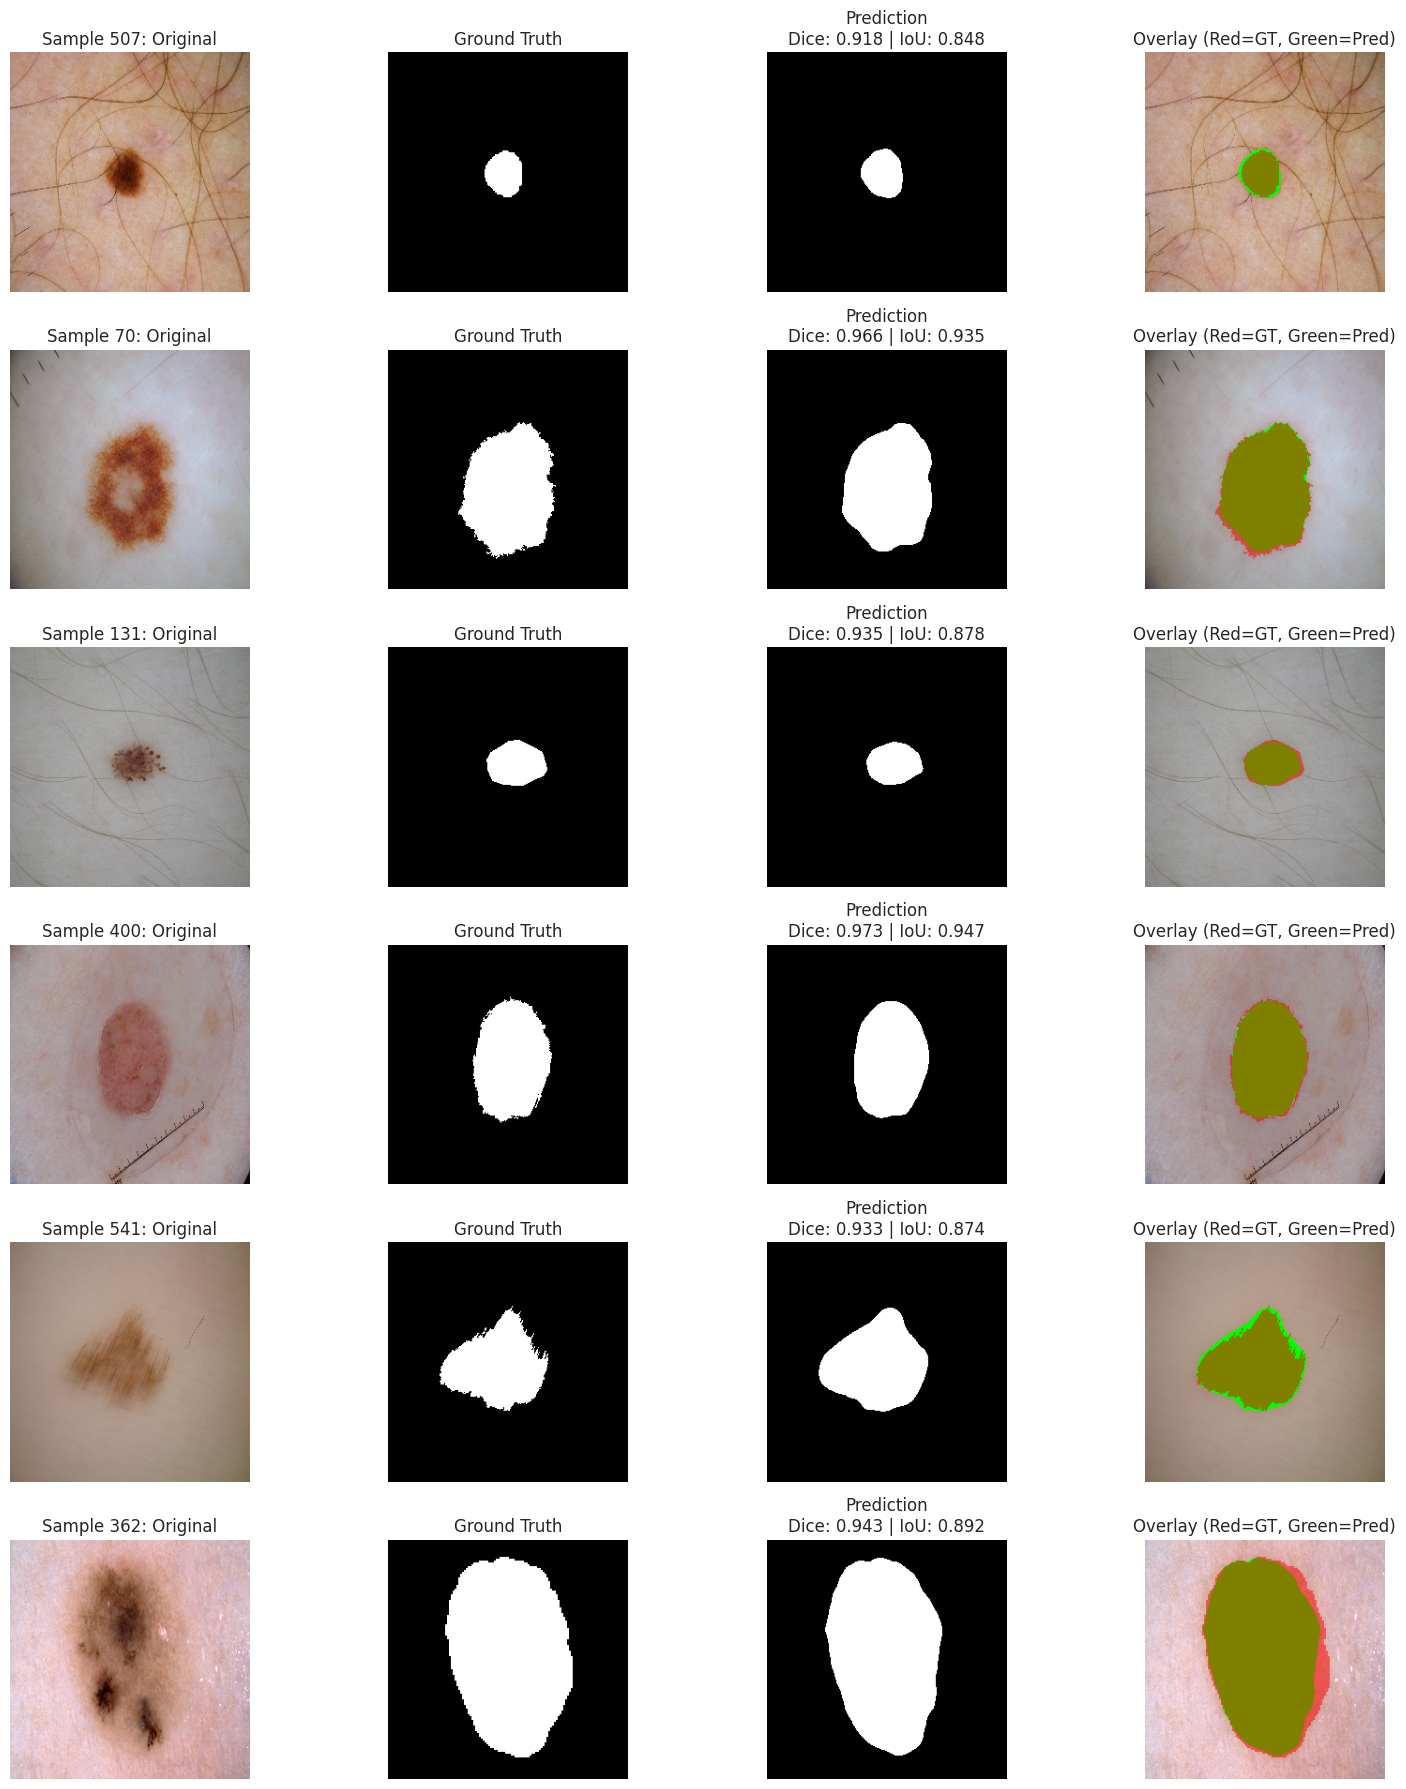


[Step 5/5] Saving test results...
✅ Test results saved to: output/test_results.json

✅ TESTING COMPLETED SUCCESSFULLY!


In [23]:
"""
Cell 14: Test model on test set using best_model.pth
"""

print("\n" + "="*70)
print("🧪 TESTING PHASE - EVALUATING ON TEST SET")
print("="*70)

# 1. Load best model
print("\n[Step 1/5] Loading best model...")
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

# Handle DataParallel state dict
state_dict = checkpoint['model_state_dict']
if list(state_dict.keys())[0].startswith('module.'):
    # Remove 'module.' prefix from DataParallel
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    print("   ⚙️  Removed DataParallel wrapper from state dict")

model.load_state_dict(state_dict)
print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
print(f"   Best Val Dice: {checkpoint['val_dice']:.4f}")
print(f"   Best Val IoU: {checkpoint.get('val_iou', 'N/A')}")

# 2. Create test dataset and dataloader
print("\n[Step 2/5] Creating test dataset...")
test_dataset = ISICDataset(
    IMG_DIRS['test'], 
    MASK_DIRS['test'], 
    transform=get_transforms('test', CONFIG['data']['input_size'])
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['data']['num_workers'],
    pin_memory=CONFIG['data']['pin_memory'],
)

print(f"✅ Test dataset created:")
print(f"   Test samples: {len(test_dataset):,}")
print(f"   Test batches: {len(test_loader)}")

# 3. Evaluate on test set
print("\n[Step 3/5] Evaluating on test set...")

def test_model(model, loader, device):
    """Test the model and return detailed metrics"""
    model.eval()
    
    all_dice_scores = []
    all_iou_scores = []
    all_losses = []  # Track per-batch losses for debugging
    
    # Weighted loss calculation (correct for variable batch sizes)
    loss_sum = 0.0
    sample_count = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Testing")
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            logits = model(images)
            
            # Calculate loss
            loss = combined_loss(
                logits, masks,
                bce_weight=CONFIG['training']['loss_weights']['bce'],
                dice_weight=CONFIG['training']['loss_weights']['dice']
            )
            
            # Calculate metrics for each sample in batch
            batch_size = images.size(0)
            for i in range(batch_size):
                dice = dice_coefficient(logits[i:i+1], masks[i:i+1])
                iou = iou_score(logits[i:i+1], masks[i:i+1])
                all_dice_scores.append(dice)
                all_iou_scores.append(iou)
            
            # Accumulate weighted loss (important for last batch if smaller)
            all_losses.append(loss.item())
            loss_sum += loss.item() * batch_size
            sample_count += batch_size
            
            pbar.set_postfix({
                'dice': f'{np.mean(all_dice_scores):.4f}',
                'iou': f'{np.mean(all_iou_scores):.4f}',
                'loss': f'{loss_sum / sample_count:.4f}'
            })
    
    return {
        'dice_scores': all_dice_scores,
        'iou_scores': all_iou_scores,
        'losses': all_losses,
        'mean_dice': np.mean(all_dice_scores),
        'std_dice': np.std(all_dice_scores),
        'mean_iou': np.mean(all_iou_scores),
        'std_iou': np.std(all_iou_scores),
        'mean_loss': loss_sum / sample_count,  # Weighted average across all samples
    }

test_metrics = test_model(model, test_loader, device)

# 4. Print test results
print("\n" + "="*70)
print("📊 TEST SET RESULTS")
print("="*70)
print(f"\n🎯 Overall Metrics:")
print(f"   Test Dice Score: {test_metrics['mean_dice']:.4f} ± {test_metrics['std_dice']:.4f}")
print(f"   Test IoU Score:  {test_metrics['mean_iou']:.4f} ± {test_metrics['std_iou']:.4f}")
print(f"   Test Loss:       {test_metrics['mean_loss']:.4f}")

print(f"\n📈 Distribution Statistics:")
print(f"   Min Dice: {min(test_metrics['dice_scores']):.4f}")
print(f"   Max Dice: {max(test_metrics['dice_scores']):.4f}")
print(f"   Median Dice: {np.median(test_metrics['dice_scores']):.4f}")
print(f"   Min IoU: {min(test_metrics['iou_scores']):.4f}")
print(f"   Max IoU: {max(test_metrics['iou_scores']):.4f}")
print(f"   Median IoU: {np.median(test_metrics['iou_scores']):.4f}")

# 5. Visualize test predictions
print("\n[Step 4/5] Visualizing test predictions...")

def visualize_test_predictions(model, dataset, device, num_samples=6):
    """Visualize predictions on test samples"""
    model.eval()
    
    # Denormalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*3))
    
    # Select random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            image_batch = image.unsqueeze(0).to(device)
            logits = model(image_batch)
            pred_mask = torch.sigmoid(logits).squeeze().cpu().numpy()
            pred_binary = (pred_mask > 0.5).astype(np.float32)
            
            # Denormalize image
            img_np = image.numpy().transpose(1, 2, 0)
            img_np = (img_np * std + mean).clip(0, 1)
            
            # Ground truth mask
            gt_mask = mask.squeeze().numpy()
            
            # Calculate metrics for this sample
            dice = dice_coefficient(logits.cpu(), mask.unsqueeze(0))
            iou = iou_score(logits.cpu(), mask.unsqueeze(0))
            
            # Plot
            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title(f'Sample {idx}: Original')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(gt_mask, cmap='gray')
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_binary, cmap='gray')
            axes[i, 2].set_title(f'Prediction\nDice: {dice:.3f} | IoU: {iou:.3f}')
            axes[i, 2].axis('off')
            
            # Overlay
            overlay = img_np.copy()
            overlay[pred_binary > 0.5] = [0, 1, 0]  # Green for prediction
            overlay[gt_mask > 0.5] = overlay[gt_mask > 0.5] * 0.5 + np.array([1, 0, 0]) * 0.5  # Red for GT
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay (Red=GT, Green=Pred)')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    save_path = CONFIG['paths']['output_dir'] / 'test_predictions.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Test predictions saved to: {save_path}")
    plt.show()

visualize_test_predictions(model, test_dataset, device, num_samples=6)

# 6. Save test results
print("\n[Step 5/5] Saving test results...")
test_results_path = CONFIG['paths']['output_dir'] / 'test_results.json'
with open(test_results_path, 'w') as f:
    json.dump({
        'test_metrics': {
            'mean_dice': float(test_metrics['mean_dice']),
            'std_dice': float(test_metrics['std_dice']),
            'mean_iou': float(test_metrics['mean_iou']),
            'std_iou': float(test_metrics['std_iou']),
            'mean_loss': float(test_metrics['mean_loss']),
            'min_dice': float(min(test_metrics['dice_scores'])),
            'max_dice': float(max(test_metrics['dice_scores'])),
            'median_dice': float(np.median(test_metrics['dice_scores'])),
        },
        'num_test_samples': len(test_dataset),
        'model_checkpoint_epoch': checkpoint['epoch'],
        'best_val_dice': float(checkpoint['val_dice']),
    }, f, indent=2)
print(f"✅ Test results saved to: {test_results_path}")

print("\n" + "="*70)
print("✅ TESTING COMPLETED SUCCESSFULLY!")
print("="*70)